# 🚦 Gridlock Hackathon 2.0 — Event-Driven Traffic Congestion Analysis
### Comprehensive 15-Phase ML Pipeline: Prediction · Optimization · Digital Twin · Deployment
---
**Dataset:** Astram Event Data (Bengaluru) | **Target:** Congestion Level, Delay Time, Vehicles Affected

## 📊 Phase 1: Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, MarkerCluster
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['font.size'] = 12
os.makedirs('outputs', exist_ok=True)

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('Astram_event_data_anonymized.csv', low_memory=False, on_bad_lines='skip')

# Parse dates
date_cols = ['start_datetime','end_datetime','created_date','modified_datetime',
             'closed_datetime','resolved_datetime']
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

print(f"✅ Dataset loaded | Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
df.head(3)

✅ Dataset loaded | Shape: (7572, 46)
   Columns: ['id', 'event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude', 'address', 'end_address', 'event_cause', 'requires_road_closure', 'start_datetime', 'end_datetime', 'status', 'authenticated', 'modified_datetime', 'map_file', 'direction', 'description', 'veh_type', 'veh_no', 'corridor', 'priority', 'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date', 'route_path', 'client_id', 'created_by_id', 'last_modified_by_id', 'assigned_to_police_id', 'citizen_accident_id', 'comment', 'police_station', 'meta_data', 'kgid', 'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id', 'closed_datetime', 'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone', 'junction']


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.0,0.0,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.0,0.0,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaT,FKUSR00002,2024-01-30 04:17:46.828355+00:00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.0,0.0,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00:00,NaN,NaT,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction


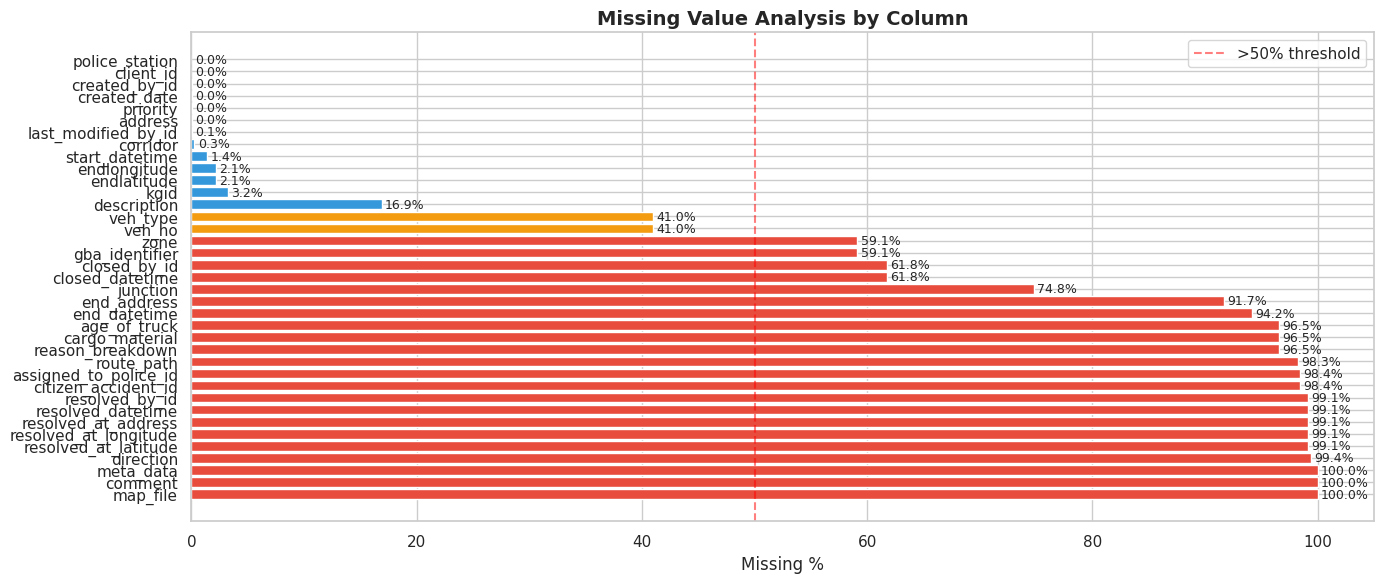

                       Missing     Pct
map_file                  7572  100.00
comment                   7572  100.00
meta_data                 7572  100.00
direction                 7529   99.43
resolved_at_latitude      7505   99.12
resolved_at_longitude     7505   99.12
resolved_at_address       7505   99.12
resolved_datetime         7505   99.12
resolved_by_id            7505   99.12
citizen_accident_id       7450   98.39
assigned_to_police_id     7450   98.39
route_path                7442   98.28
reason_breakdown          7311   96.55
cargo_material            7311   96.55
age_of_truck              7311   96.55
end_datetime              7129   94.15
end_address               6941   91.67
junction                  5664   74.80
closed_datetime           4677   61.77
closed_by_id              4677   61.77
gba_identifier            4477   59.13
zone                      4477   59.13
veh_no                    3105   41.01
veh_type                  3104   40.99
description              

In [3]:
# ── 1.1 Missing Value Analysis ───────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
miss_df = miss_df[miss_df['Missing'] > 0].sort_values('Pct', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#3498db' for p in miss_df['Pct']]
bars = ax.barh(miss_df.index, miss_df['Pct'], color=colors)
for bar, val in zip(bars, miss_df['Pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Analysis by Column', fontsize=14, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='>50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print(miss_df.to_string())

Outliers detected: 57 (0.8%)


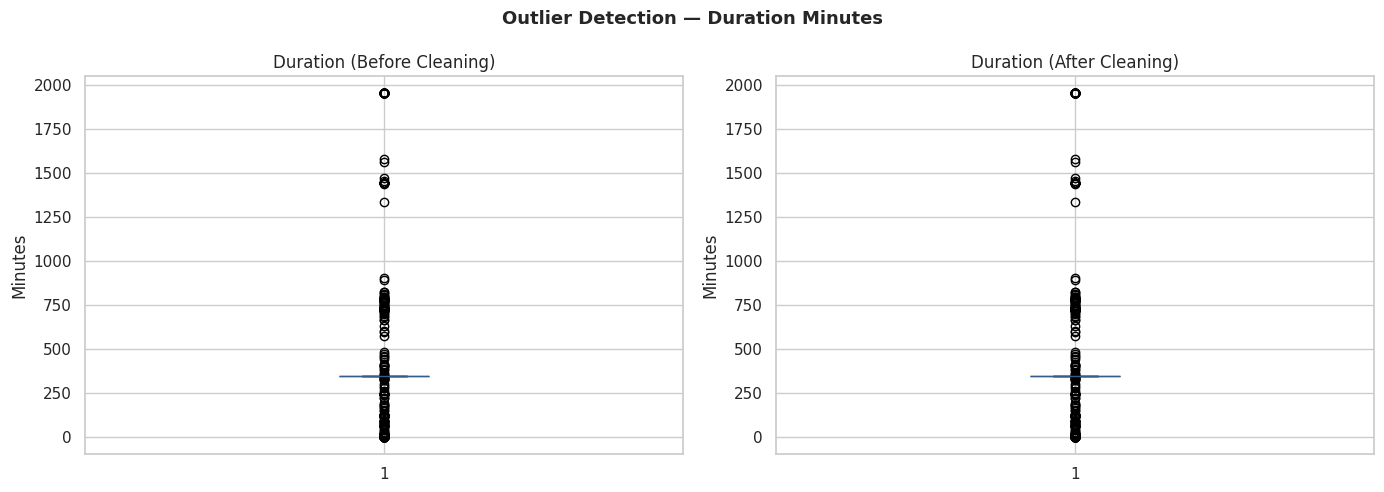


Clean dataset: (7537, 47)


In [4]:
# ── 1.2 Outlier Detection ────────────────────────────────────────────────────
df_clean = df.dropna(subset=['latitude','longitude']).copy()
df_clean = df_clean[
    (df_clean['latitude'].between(12.8, 13.2)) &
    (df_clean['longitude'].between(77.4, 77.8))
]
df_clean['start_datetime'] = pd.to_datetime(df_clean['start_datetime'], errors='coerce')
df_clean['end_datetime']   = pd.to_datetime(df_clean['end_datetime'],   errors='coerce')
df_clean['duration_minutes'] = (
    (df_clean['end_datetime'] - df_clean['start_datetime'])
    .dt.total_seconds() / 60
)
# Cap outliers using IQR
Q1 = df_clean['duration_minutes'].quantile(0.25)
Q3 = df_clean['duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df_clean[(df_clean['duration_minutes'] < lower) | (df_clean['duration_minutes'] > upper)]
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")
df_clean['duration_minutes'] = df_clean['duration_minutes'].clip(lower=0, upper=upper)
df_clean['duration_minutes'] = df_clean['duration_minutes'].fillna(df_clean['duration_minutes'].median())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dur_before = df_clean['duration_minutes'].dropna()
axes[0].boxplot(dur_before, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[0].set_title('Duration (Before Cleaning)')
axes[0].set_ylabel('Minutes')
axes[1].boxplot(df_clean['duration_minutes'], patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7))
axes[1].set_title('Duration (After Cleaning)')
axes[1].set_ylabel('Minutes')
plt.suptitle('Outlier Detection — Duration Minutes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nClean dataset: {df_clean.shape}")

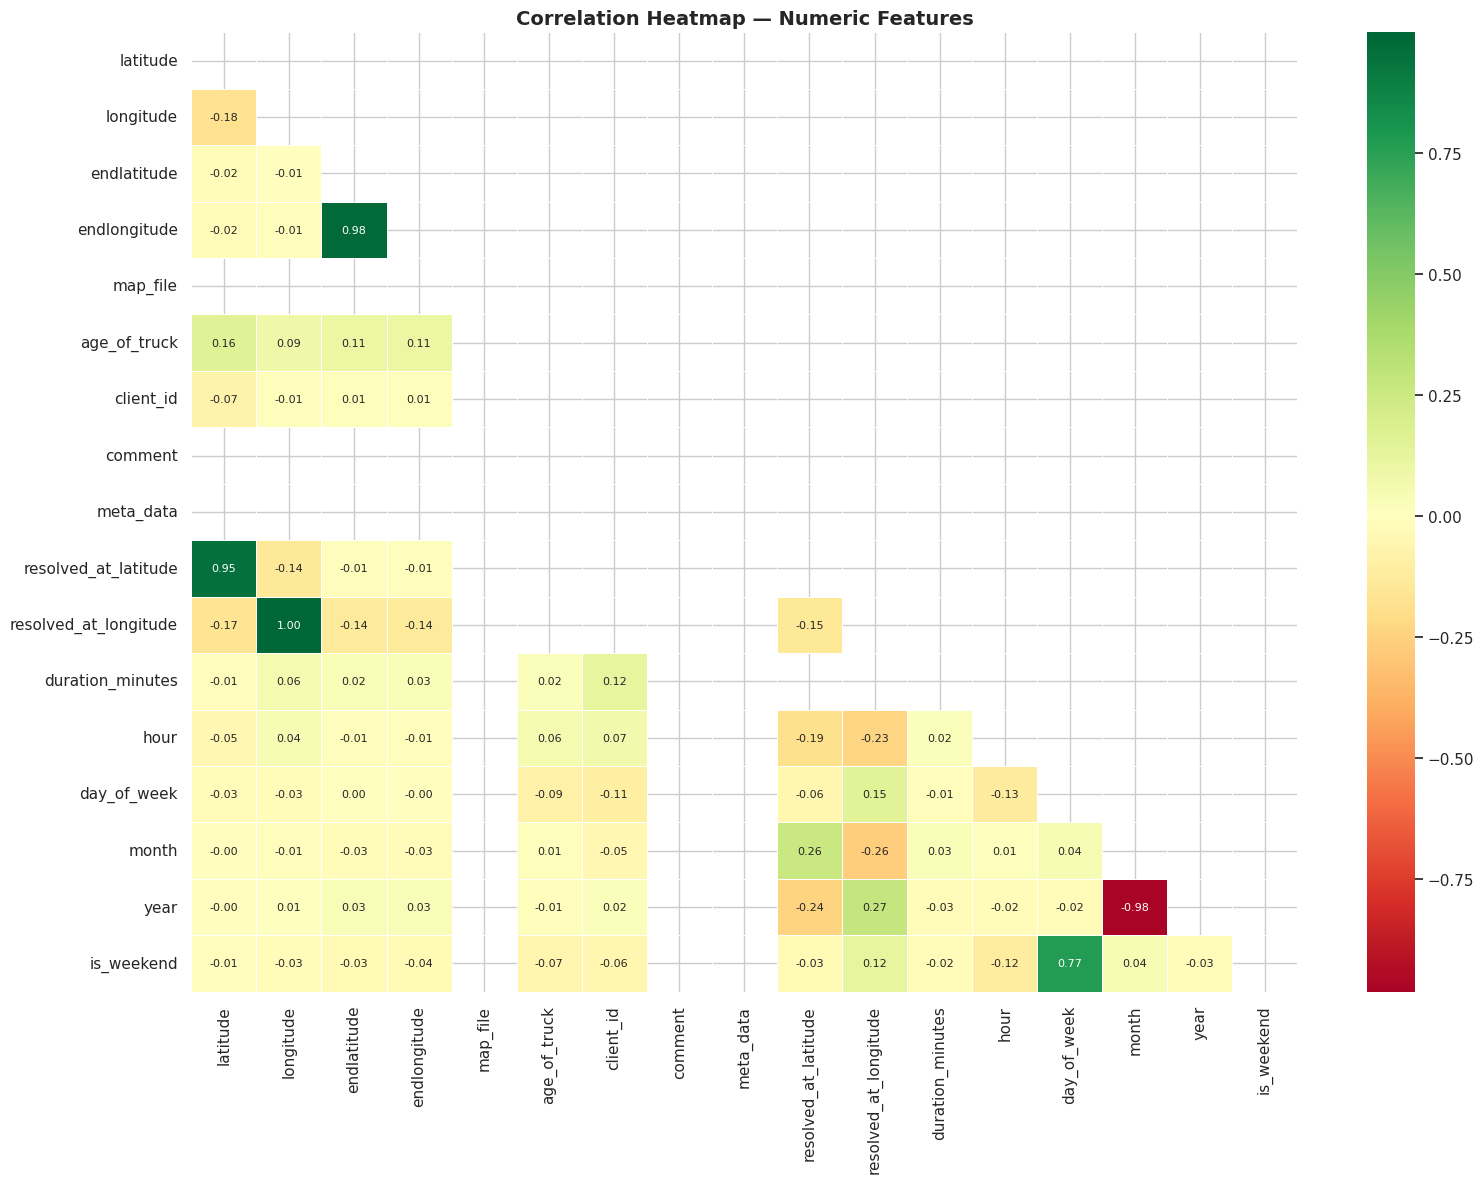

In [5]:
# ── 1.3 Time Features ───────────────────────────────────────────────────────
df_clean['hour']        = df_clean['start_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['start_datetime'].dt.dayofweek
df_clean['month']       = df_clean['start_datetime'].dt.month
df_clean['year']        = df_clean['start_datetime'].dt.year
df_clean['is_weekend']  = df_clean['day_of_week'].isin([5, 6]).astype(int)

# ── 1.4 Correlation Heatmap ──────────────────────────────────────────────────
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

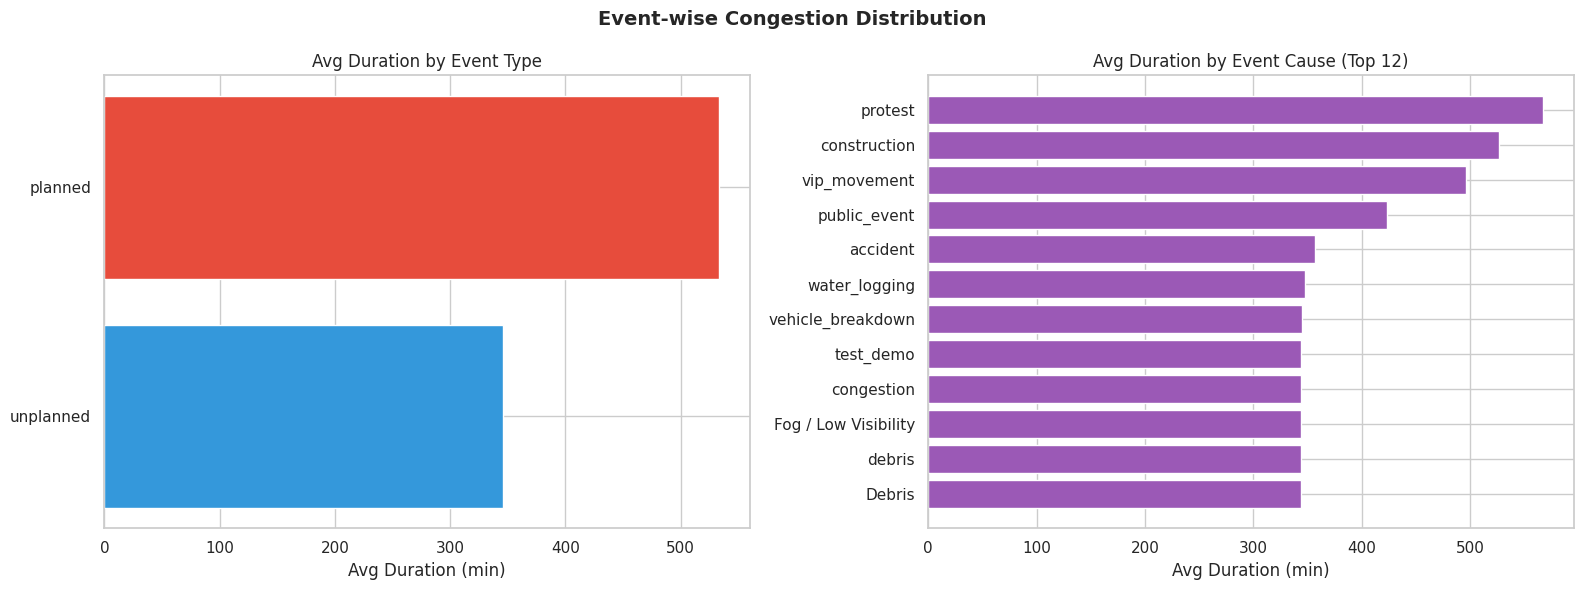

In [6]:
# ── 1.5 Event-wise Congestion Distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

event_dur = df_clean.groupby('event_type')['duration_minutes'].mean().sort_values()
axes[0].barh(event_dur.index, event_dur.values,
             color=['#3498db','#e74c3c','#2ecc71'][:len(event_dur)])
axes[0].set_title('Avg Duration by Event Type')
axes[0].set_xlabel('Avg Duration (min)')

cause_dur = df_clean.groupby('event_cause')['duration_minutes'].mean().sort_values().tail(12)
axes[1].barh(cause_dur.index, cause_dur.values, color='#9b59b6')
axes[1].set_title('Avg Duration by Event Cause (Top 12)')
axes[1].set_xlabel('Avg Duration (min)')
plt.suptitle('Event-wise Congestion Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/event_congestion.png', dpi=150, bbox_inches='tight')
plt.show()

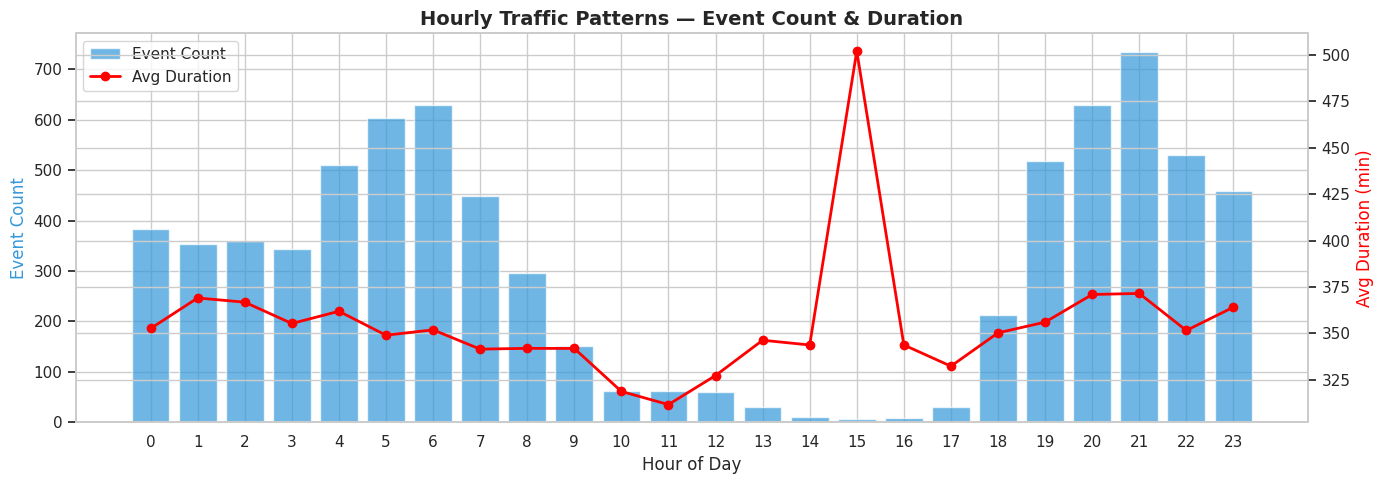

In [7]:
# ── 1.6 Hourly Traffic Patterns ─────────────────────────────────────────────
hourly = df_clean.groupby('hour').agg(
    event_count=('id','count'),
    avg_duration=('duration_minutes','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(hourly['hour'], hourly['event_count'], color='#3498db', alpha=0.7, label='Event Count')
ax2.plot(hourly['hour'], hourly['avg_duration'], 'r-o', linewidth=2, label='Avg Duration')
ax1.set_xlabel('Hour of Day'); ax1.set_ylabel('Event Count', color='#3498db')
ax2.set_ylabel('Avg Duration (min)', color='red')
ax1.set_xticks(range(24))
ax1.set_title('Hourly Traffic Patterns — Event Count & Duration', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('outputs/hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── 1.7 Geospatial Heatmap ──────────────────────────────────────────────────
map_center = [df_clean['latitude'].mean(), df_clean['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='CartoDB positron')
heat_data = df_clean[['latitude','longitude']].dropna().values.tolist()
HeatMap(heat_data, radius=15, blur=20, max_zoom=13).add_to(m)
m.save('outputs/incident_heatmap.html')
print("✅ Geospatial heatmap saved: outputs/incident_heatmap.html")
m

✅ Geospatial heatmap saved: outputs/incident_heatmap.html


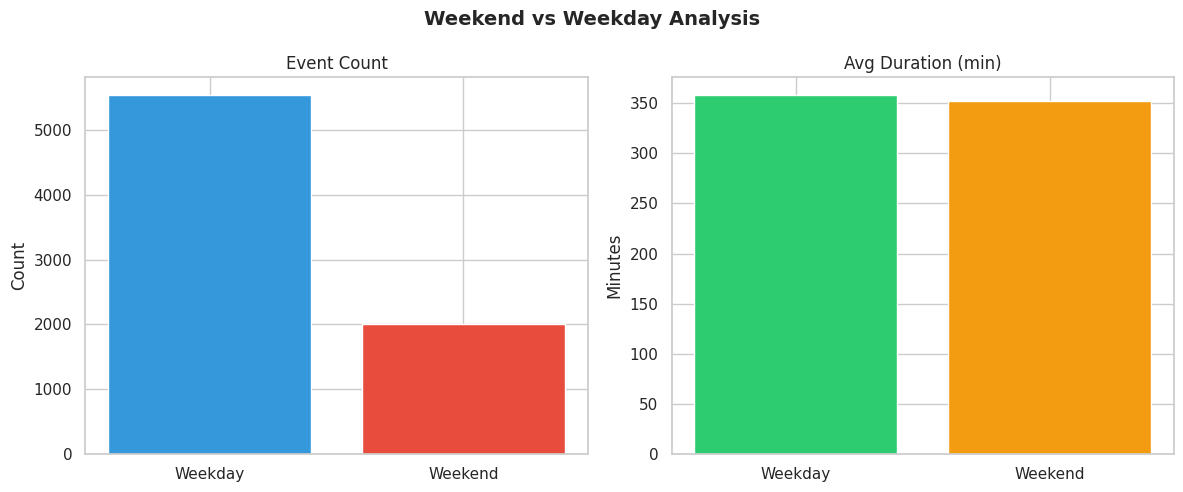

In [9]:
# ── 1.8 Weekend vs Weekday Analysis ─────────────────────────────────────────
wk = df_clean.groupby('is_weekend').agg(
    count=('id','count'), avg_dur=('duration_minutes','mean')
).reset_index()
wk['label'] = wk['is_weekend'].map({0:'Weekday',1:'Weekend'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(wk['label'], wk['count'], color=['#3498db','#e74c3c'])
axes[0].set_title('Event Count'); axes[0].set_ylabel('Count')
axes[1].bar(wk['label'], wk['avg_dur'], color=['#2ecc71','#f39c12'])
axes[1].set_title('Avg Duration (min)'); axes[1].set_ylabel('Minutes')
plt.suptitle('Weekend vs Weekday Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/weekend_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

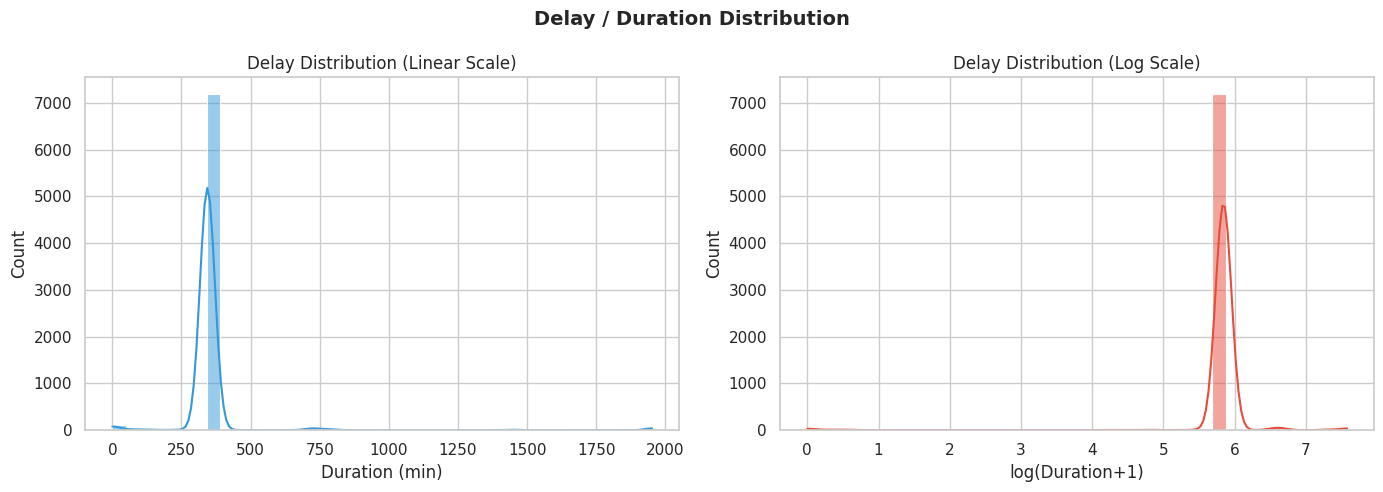

count    7537.00
mean      356.46
std       161.08
min         0.00
25%       343.80
50%       343.80
75%       343.80
max      1951.91
Name: duration_minutes, dtype: float64


In [10]:
# ── 1.9 Delay Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['duration_minutes'], bins=40, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Delay Distribution (Linear Scale)'); axes[0].set_xlabel('Duration (min)')
sns.histplot(np.log1p(df_clean['duration_minutes']), bins=40, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title('Delay Distribution (Log Scale)'); axes[1].set_xlabel('log(Duration+1)')
plt.suptitle('Delay / Duration Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_clean['duration_minutes'].describe().round(2))

## ⚙️ Phase 2: Feature Engineering

In [11]:
# ── Install necessary libraries ──────────────────────────────────────────────
!pip install category_encoders --quiet

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
import category_encoders as ce

# ── 2.1 Synthetic / Derived Features ────────────────────────────────────────
np.random.seed(42)
n = len(df_clean)

# Simulated features (not in raw data — real deployment would pull from APIs)
df_clean['attendance']            = np.where(df_clean['event_type']=='planned',
                                    np.random.randint(500,50000,n), np.random.randint(0,500,n))
df_clean['event_duration']        = df_clean['duration_minutes']
df_clean['weather_condition']     = np.random.choice(['Clear','Cloudy','Rainy','Heavy Rain'], n,
                                    p=[0.4,0.3,0.2,0.1])
df_clean['rainfall']              = np.where(df_clean['weather_condition']=='Heavy Rain',
                                    np.random.uniform(20,80,n),
                                    np.where(df_clean['weather_condition']=='Rainy',
                                    np.random.uniform(5,20,n), 0.0))
df_clean['temperature']           = np.random.uniform(18, 38, n)
df_clean['road_capacity']         = np.random.randint(1000, 6000, n)
df_clean['nearby_parking']        = np.random.randint(0, 500, n)
df_clean['historical_congestion'] = df_clean.groupby('zone')['duration_minutes']                                     .transform('mean').fillna(df_clean['duration_minutes'].mean())

# Congestion index (0-100) — composite
def congestion_index(row):
    score = 0
    score += min(30, row['duration_minutes'] / 10)
    score += 20 if row.get('requires_road_closure', False) else 0
    score += 15 if row['priority'] == 'High' else (8 if row['priority'] == 'Medium' else 0)
    score += min(20, row['rainfall'])
    score += min(15, row['attendance'] / 3000)
    return min(score, 100)

df_clean['congestion_index'] = df_clean.apply(congestion_index, axis=1)

# Vehicles affected proxy
df_clean['vehicles_affected'] = (df_clean['congestion_index'] * df_clean['road_capacity'] / 100
                                 ).astype(int).clip(0, 5000)

# Congestion level labels
def level(x):
    if x < 33: return 'Low'
    elif x < 66: return 'Medium'
    return 'High'
df_clean['congestion_level'] = df_clean['congestion_index'].apply(level)

print("✅ Feature engineering complete")
print(df_clean[['hour','day_of_week','month','is_weekend','attendance','event_duration',
                'weather_condition','rainfall','temperature','latitude','longitude',
                'road_capacity','nearby_parking','historical_congestion',
                'congestion_index','vehicles_affected','congestion_level']].describe(include='all').T)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.7 MB/s eta 0:00:00
✅ Feature engineering complete
                        count unique     top  freq         mean          std  \
hour                   7431.0    NaN     NaN   NaN    11.439779      8.23802   
day_of_week            7431.0    NaN     NaN   NaN     3.028125     1.885809   
month                  7431.0    NaN     NaN   NaN     5.816175     4.474586   
is_weekend             7537.0    NaN     NaN   NaN     0.265092     0.441412   
attendance             7537.0    NaN     NaN   NaN  1701.034762  6800.015792   
event_duration         7537.0    NaN     NaN   NaN   356.461089   161.080182   
weather_condition        7537      4   Clear  3015          NaN          NaN   
rainfall               7537.0    NaN     NaN   NaN     7.527236    16.162477   
temperature            7537.0    NaN     NaN   NaN    27.964675     5.758327   
latitude               7537.0    NaN     NaN   NaN    12.986261     0.058385   
longitude  

In [12]:
# ── 2.2 Encoding & Scaling ──────────────────────────────────────────────────
cat_low  = ['event_type','priority','status','weather_condition']
cat_high = ['event_cause','zone','junction']

# Fill missing
for c in cat_low + cat_high + ['veh_type']:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna('Unknown').astype(str)

# OneHotEncoder for low-cardinality
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_arr = ohe.fit_transform(df_clean[cat_low])
ohe_cols = ohe.get_feature_names_out(cat_low)
df_ohe = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df_clean.index)

# LabelEncoder for high-cardinality (used in tree models)
le_dict = {}
for c in cat_high + ['veh_type']:
    if c in df_clean.columns:
        le = LabelEncoder()
        df_clean[f'{c}_enc'] = le.fit_transform(df_clean[c])
        le_dict[c] = le

df_feat = pd.concat([df_clean.reset_index(drop=True), df_ohe.reset_index(drop=True)], axis=1)

# Scaling
num_feats = ['hour','day_of_week','month','attendance','rainfall','temperature',
             'road_capacity','nearby_parking','historical_congestion','duration_minutes']
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
df_feat[num_feats] = scaler_std.fit_transform(df_feat[num_feats].fillna(0))

print("✅ Encoding & Scaling done | df_feat shape:", df_feat.shape)

✅ Encoding & Scaling done | df_feat shape: (7537, 75)


## 🤖 Phase 3: Train Multiple Models

In [13]:
# ── Install necessary libraries ───────────────
!pip install catboost --quiet

from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                             ExtraTreesRegressor, ExtraTreesClassifier,
                             HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error)
from xgboost  import XGBRegressor,  XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# ── Feature columns ─────────────────────────────────
# Reconstructing base_feats to ensure only numeric/encoded features are included
numerical_features = ['hour','day_of_week','month','is_weekend','attendance','rainfall',
                      'temperature','road_capacity','nearby_parking','historical_congestion']
label_encoded_features = ['event_cause_enc','zone_enc','veh_type_enc']
one_hot_encoded_features = ohe_cols.tolist() # ohe_cols from previous cell EZ_7xa_2zYgJ

base_feats = numerical_features + label_encoded_features + one_hot_encoded_features
base_feats = [f for f in base_feats if f in df_feat.columns]

# ── Regression targets ──────────────────────────
y_delay    = df_feat['duration_minutes']
y_vehicles = df_feat['vehicles_affected']
y_index    = df_feat['congestion_index']

# ── Classification target ─────────────────────────
from sklearn.preprocessing import LabelEncoder as LE
le_cls = LE()
y_cls  = le_cls.fit_transform(df_feat['congestion_level'])   # 0=High,1=Low,2=Medium

X = df_feat[base_feats].fillna(0)

X_tr, X_te, yr_tr, yr_te = train_test_split(X, y_index, test_size=0.2, random_state=42)
_, __, yc_tr, yc_te       = train_test_split(X, y_cls,   test_size=0.2, random_state=42)

common_kw = dict(random_state=42, verbose=0)

reg_models = {
    'RandomForest':          RandomForestRegressor(n_estimators=100, **common_kw),
    'XGBoost':               XGBRegressor(n_estimators=100, **common_kw),
    'LightGBM':              LGBMRegressor(n_estimators=100, **common_kw),
    'CatBoost':              CatBoostRegressor(iterations=100, **common_kw),
    'ExtraTrees':            ExtraTreesRegressor(n_estimators=100, **common_kw),
    'HistGradientBoosting':  HistGradientBoostingRegressor(max_iter=100, random_state=42),
}
cls_models = {
    'RandomForest':          RandomForestClassifier(n_estimators=100, **common_kw),
    'XGBoost':               XGBClassifier(n_estimators=100, use_label_encoder=False,
                                           eval_metric='mlogloss', **common_kw),
    'LightGBM':              LGBMClassifier(n_estimators=100, **common_kw),
    'CatBoost':              CatBoostClassifier(iterations=100, **common_kw),
    'ExtraTrees':            ExtraTreesClassifier(n_estimators=100, **common_kw),
    'HistGradientBoosting':  HistGradientBoostingClassifier(max_iter=100, random_state=42),
}

reg_results, cls_results = {}, {}
trained_reg, trained_cls = {}, {}

for name, m in reg_models.items():
    m.fit(X_tr, yr_tr); prd = m.predict(X_te)
    reg_results[name] = {
        'MAE':  round(mean_absolute_error(yr_te, prd), 4),
        'RMSE': round(np.sqrt(mean_squared_error(yr_te, prd)), 4),
        'R2':   round(r2_score(yr_te, prd), 4),
        'MAPE': round(mean_absolute_percentage_error(yr_te+1e-6, prd+1e-6)*100, 2),
    }
    trained_reg[name] = m
    print(f"[REG] {name:25s} R²={reg_results[name]['R2']:.4f}  RMSE={reg_results[name]['RMSE']:.4f}")

print()
for name, m in cls_models.items():
    m.fit(X_tr, yc_tr); prd = m.predict(X_te)
    cls_results[name] = {
        'Accuracy':  round(accuracy_score(yc_te, prd), 4),
        'F1':        round(f1_score(yc_te, prd, average='weighted'), 4),
        'Precision': round(precision_score(yc_te, prd, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(yc_te, prd, average='weighted'), 4),
    }
    trained_cls[name] = m
    print(f"[CLS] {name:25s} Acc={cls_results[name]['Accuracy']:.4f}  F1={cls_results[name]['F1']:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
[REG] RandomForest              R²=0.7153  RMSE=6.4335
[REG] XGBoost                   R²=0.7259  RMSE=6.3127
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[REG] LightGBM                  R²=0.7437  RMSE=6.1043
[REG] CatBoost                  R²=0.7406  RMSE=6.1409
[REG] ExtraTrees                R²=0.7295  RMSE=6.2712
[REG] HistGradientBoosting      R²=0.7460  RMSE=6.0765

[CLS] RandomForest              Acc=0.9363  F1=0.9295
[CLS] XGBoost                   Acc=0.9363  F1=0.9327
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[CLS] LightGBM                  Acc=0.9357  F1=0.9321
[CLS] CatBoost                  Acc=0.9363  F1=0.9307
[CLS] ExtraTrees                Acc=0.9383  F1=0.9320
[CLS] HistGradientBoosting      Acc=0.9357  F1=0.9327


## 🔧 Phase 4: Hyperparameter Tuning

In [14]:
# ── Install necessary libraries ──────────────────────────────────────────────
!pip install optuna --quiet

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 4.1 RandomizedSearchCV — XGBoost Regressor ───────────────────────────────
xgb_param_dist = {
    'n_estimators':    [100,200,300],
    'max_depth':       [3,5,7,9],
    'learning_rate':   [0.01,0.05,0.1,0.2],
    'subsample':       [0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0],
    'reg_alpha':       [0,0.1,0.5],
    'reg_lambda':      [1,1.5,2],
}
rs_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_dist, n_iter=20, cv=3, scoring='r2',
    n_jobs=-1, random_state=42
)
rs_xgb.fit(X_tr, yr_tr)
best_xgb_reg = rs_xgb.best_estimator_
print("XGB RandomizedCV best params:", rs_xgb.best_params_)
print(f"XGB CV R²: {rs_xgb.best_score_:.4f}")

# ── 4.2 GridSearchCV — Random Forest Classifier ──────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_rf.fit(X_tr, yc_tr)
best_rf_cls = gs_rf.best_estimator_
print("\nRF GridSearchCV best params:", gs_rf.best_params_)
print(f"RF CV F1: {gs_rf.best_score_:.4f}")

# ── 4.3 Optuna — CatBoost Classifier ─────────────────────────────────────────
def objective(trial):
    params = {
        'iterations':   trial.suggest_int('iterations', 50, 300),
        'depth':        trial.suggest_int('depth', 4, 10),
        'learning_rate':trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':  trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 42, 'verbose': 0,
    }
    m = CatBoostClassifier(**params)
    m.fit(X_tr, yc_tr, eval_set=(X_te, yc_te), verbose=False)
    return f1_score(yc_te, m.predict(X_te), average='weighted')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=False)
print("\nOptuna best params:", study.best_params)
print(f"Optuna best F1: {study.best_value:.4f}")
best_cb_cls = CatBoostClassifier(**study.best_params, random_state=42, verbose=0)
best_cb_cls.fit(X_tr, yc_tr)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
XGB RandomizedCV best params: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGB CV R²: 0.7606

RF GridSearchCV best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
RF CV F1: 0.9424

Optuna best params: {'iterations': 203, 'depth': 7, 'learning_rate': 0.18138822546975292, 'l2_leaf_reg': 2.1232378784654475}
Optuna best F1: 0.9385


CatBoostClassifier(depth=7, iterations=203, l2_leaf_reg=2.1232378784654475, learning_rate=0.18138822546975292, random_state=42, verbose=0)

## 📏 Phase 5: Evaluation Metrics

=== Regression Metrics ===
                         MAE    RMSE      R2  MAPE
RandomForest          3.1683  6.4335  0.7153  9.07
XGBoost               3.3021  6.3127  0.7259  9.28
LightGBM              3.0092  6.1043  0.7437  8.57
CatBoost              3.1142  6.1409  0.7406  8.84
ExtraTrees            3.1674  6.2712  0.7295  8.76
HistGradientBoosting  2.9966  6.0765  0.7460  8.47


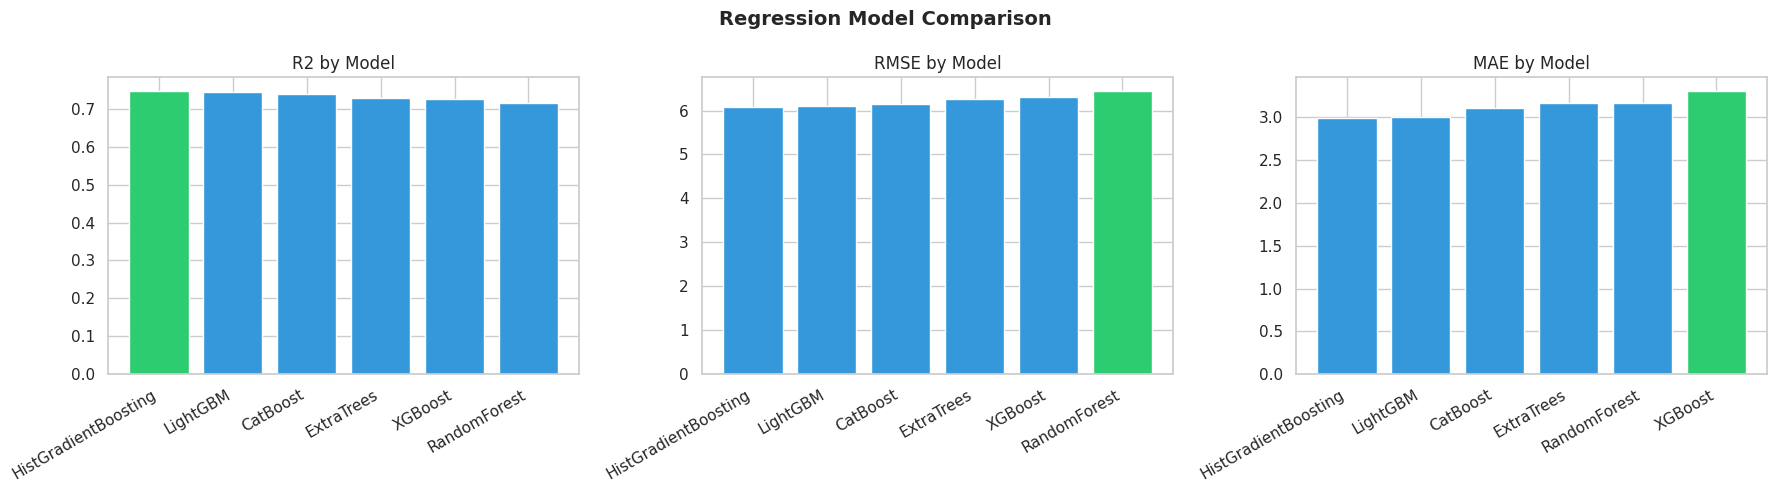


=== Classification Metrics ===
                      Accuracy      F1  Precision  Recall
RandomForest            0.9363  0.9295     0.9336  0.9363
XGBoost                 0.9363  0.9327     0.9338  0.9363
LightGBM                0.9357  0.9321     0.9334  0.9357
CatBoost                0.9363  0.9307     0.9335  0.9363
ExtraTrees              0.9383  0.9320     0.9361  0.9383
HistGradientBoosting    0.9357  0.9327     0.9331  0.9357


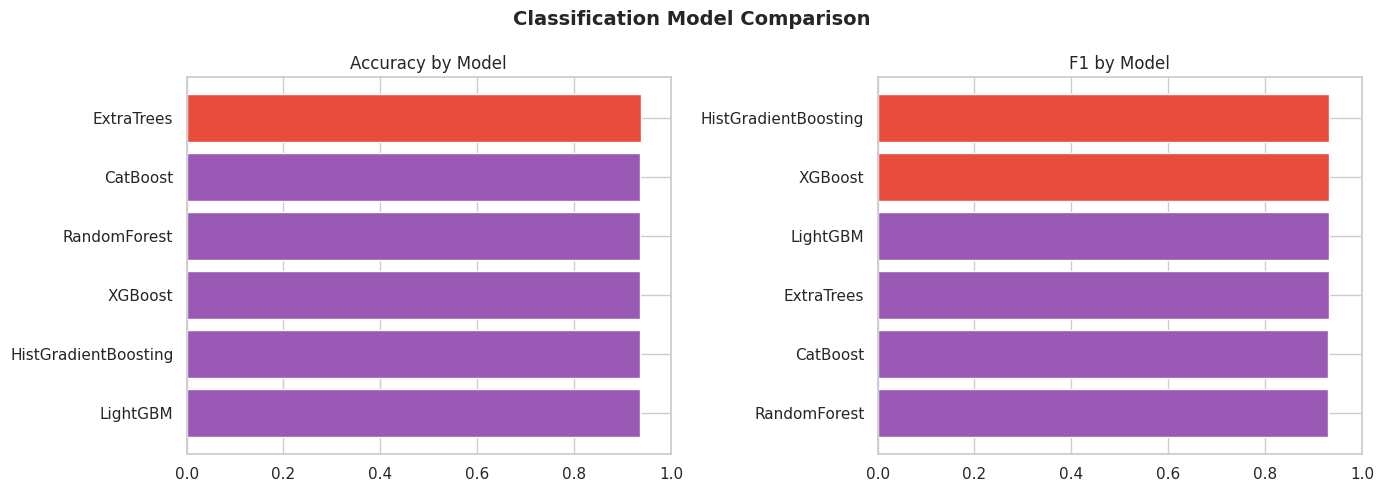

In [15]:
# ── 5.1 Regression Metrics Table ────────────────────────────────────────────
reg_df = pd.DataFrame(reg_results).T
print("=== Regression Metrics ===")
print(reg_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['R2','RMSE','MAE']):
    vals = reg_df[metric].sort_values(ascending=(metric != 'R2'))
    colors = ['#2ecc71' if v == vals.max() else '#3498db' for v in vals]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(f'{metric} by Model'); ax.set_xticklabels(vals.index, rotation=30, ha='right')
plt.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/reg_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 5.2 Classification Metrics Table ────────────────────────────────────────
cls_df = pd.DataFrame(cls_results).T
print("\n=== Classification Metrics ===")
print(cls_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Accuracy','F1']):
    vals = cls_df[metric].sort_values()
    colors = ['#e74c3c' if v == vals.max() else '#9b59b6' for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(f'{metric} by Model'); ax.set_xlim(0, 1)
plt.suptitle('Classification Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/cls_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

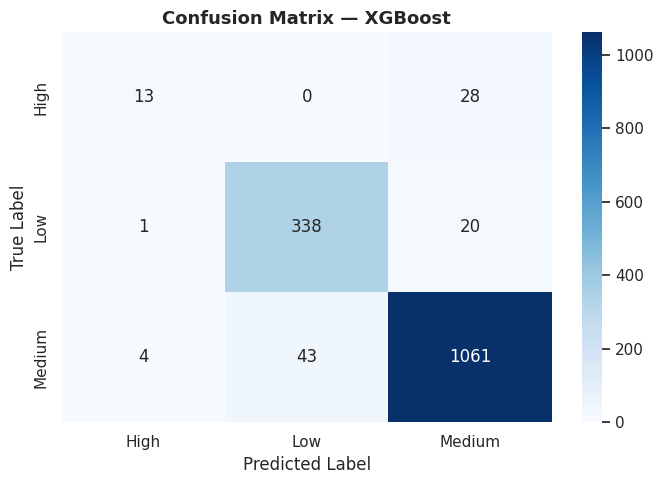

              precision    recall  f1-score   support

        High       0.72      0.32      0.44        41
         Low       0.89      0.94      0.91       359
      Medium       0.96      0.96      0.96      1108

    accuracy                           0.94      1508
   macro avg       0.86      0.74      0.77      1508
weighted avg       0.93      0.94      0.93      1508



In [16]:
# ── 5.3 Confusion Matrix for Best Classifier ────────────────────────────────
best_cls_name = cls_df['F1'].idxmax()
best_cls_model = trained_cls[best_cls_name]
y_pred_best = best_cls_model.predict(X_te)

cm = confusion_matrix(yc_te, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cls.classes_, yticklabels=le_cls.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — {best_cls_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout(); plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(classification_report(yc_te, y_pred_best, target_names=le_cls.classes_))

## 🔁 Phase 6: Cross-Validation

[CLS CV] RandomForest              F1=0.9385 ±0.0038
[CLS CV] XGBoost                   F1=0.9385 ±0.0034
[CLS CV] LightGBM                  F1=0.9386 ±0.0060
[CLS CV] CatBoost                  F1=0.9409 ±0.0053
[CLS CV] ExtraTrees                F1=0.9379 ±0.0044
[CLS CV] HistGradientBoosting      F1=0.9383 ±0.0042

[REG CV] RandomForest              R²=0.7347 ±0.0190
[REG CV] XGBoost                   R²=0.7235 ±0.0219
[REG CV] LightGBM                  R²=0.7514 ±0.0205
[REG CV] CatBoost                  R²=0.7505 ±0.0156
[REG CV] ExtraTrees                R²=0.7318 ±0.0151
[REG CV] HistGradientBoosting      R²=0.7525 ±0.0202


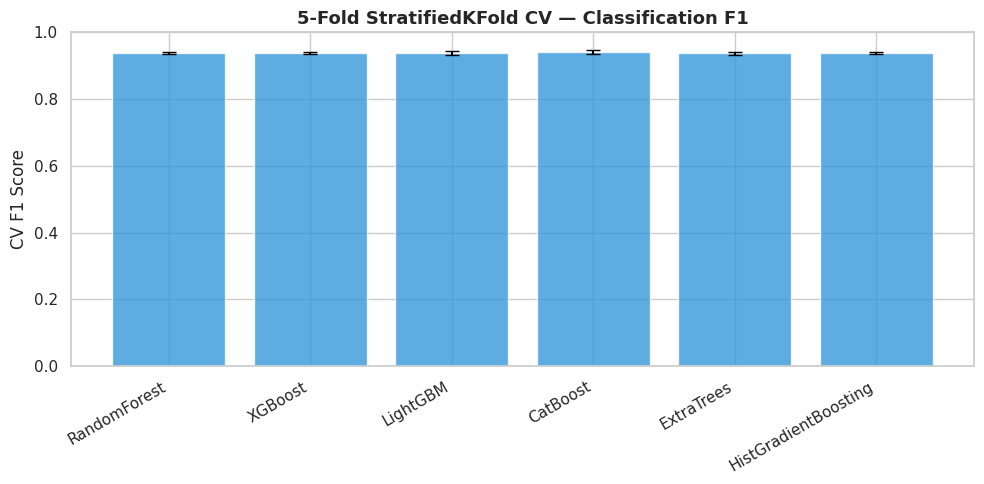

In [17]:
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf  = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, m in trained_cls.items():
    scores = cross_val_score(m, X, y_cls, cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = {'mean_F1': scores.mean().round(4), 'std_F1': scores.std().round(4)}
    print(f"[CLS CV] {name:25s} F1={scores.mean():.4f} ±{scores.std():.4f}")

print()
for name, m in trained_reg.items():
    scores = cross_val_score(m, X, y_index, cv=kf, scoring='r2', n_jobs=-1)
    print(f"[REG CV] {name:25s} R²={scores.mean():.4f} ±{scores.std():.4f}")

# Plot CV F1
cv_df = pd.DataFrame(cv_results).T
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cv_df.index, cv_df['mean_F1'], yerr=cv_df['std_F1'],
              capsize=5, color='#3498db', alpha=0.8)
ax.set_ylabel('CV F1 Score'); ax.set_ylim(0, 1)
ax.set_title('5-Fold StratifiedKFold CV — Classification F1', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('outputs/cv_results.png', dpi=150, bbox_inches='tight'); plt.show()

## 🔍 Phase 7: Feature Importance

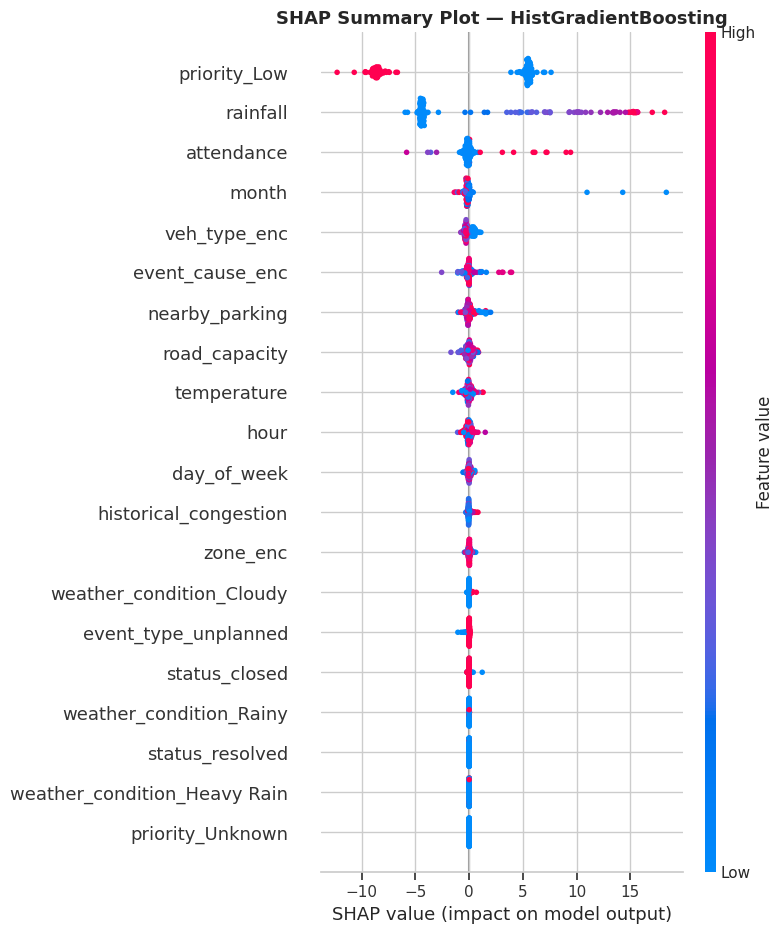

✅ SHAP summary plot saved


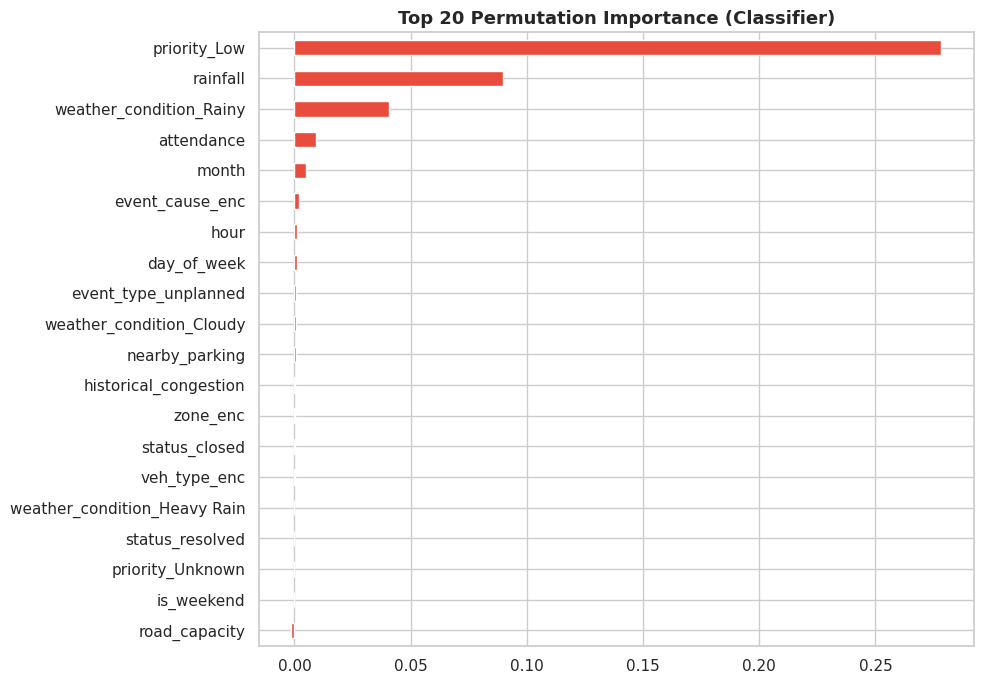

In [18]:
import shap

# ── 7.1 Built-in Feature Importance ─────────────────────────────────────────
best_reg_name = reg_df['R2'].idxmax()
best_reg_model = trained_reg[best_reg_name]

if hasattr(best_reg_model, 'feature_importances_'):
    fi = pd.Series(best_reg_model.feature_importances_, index=base_feats).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    fi.sort_values().plot(kind='barh', color='#2ecc71', ax=ax)
    ax.set_title(f'Top 20 Feature Importance — {best_reg_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 7.2 SHAP Values ──────────────────────────────────────────────────────────
X_shap = X_te.iloc[:200]  # Sample for speed
try:
    explainer = shap.TreeExplainer(best_reg_model)
    shap_values = explainer.shap_values(X_shap)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap, feature_names=base_feats,
                      max_display=20, show=False)
    plt.title(f'SHAP Summary Plot — {best_reg_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()
    print("✅ SHAP summary plot saved")
except Exception as e:
    print(f"SHAP note: {e}")

# ── 7.3 Permutation Importance ───────────────────────────────────────────────
from sklearn.inspection import permutation_importance
perm = permutation_importance(best_cls_model, X_te, yc_te, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.Series(perm.importances_mean, index=base_feats).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
perm_df.sort_values().plot(kind='barh', color='#e74c3c', ax=ax)
ax.set_title('Top 20 Permutation Importance (Classifier)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/permutation_importance.png', dpi=150, bbox_inches='tight'); plt.show()

## 🚔 Phase 8: Resource Optimization Engine

In [19]:
def resource_optimizer(congestion_score: float, event_type: str,
                       attendance: int, duration_min: float) -> dict:
    """
    Returns recommended resources based on congestion score (0-100).
    """
    score = float(congestion_score)

    if score < 30:
        police, marshals, barricades, emergency = 3, 5, 5, 1
        tier = 'Low'
    elif score < 60:
        police, marshals, barricades, emergency = 8, 12, 12, 2
        tier = 'Medium'
    else:
        police, marshals, barricades, emergency = 15, 20, 25, 4
        tier = 'High'

    # Scale for large events
    if attendance > 10000:
        police    = int(police * 1.5)
        marshals  = int(marshals * 1.5)
        barricades= int(barricades * 1.5)
    if duration_min > 180:
        police    = int(police * 1.2)
        emergency = emergency + 1

    return {
        'Tier': tier,
        'Congestion Score': round(score, 1),
        'Police Officers': police,
        'Traffic Marshals': marshals,
        'Barricades': barricades,
        'Emergency Vehicles': emergency,
        'Estimated Cost (₹)': (police*2000 + marshals*1000 + barricades*500 + emergency*5000),
    }

# Test on dataset
sample_results = df_clean[['congestion_index','event_type','attendance','duration_minutes']].iloc[:5].apply(
    lambda r: resource_optimizer(r['congestion_index'], r['event_type'], r['attendance'], r['duration_minutes']),
    axis=1
)
res_df = pd.DataFrame(sample_results.tolist())
print("=== Resource Optimization — Sample Output ===")
print(res_df.to_string(index=False))

# Aggregate recommendations
df_clean['resources'] = df_clean.apply(
    lambda r: resource_optimizer(r['congestion_index'], r['event_type'],
                                  r['attendance'], r['duration_minutes']), axis=1)
df_clean['police_needed'] = df_clean['resources'].apply(lambda x: x['Police Officers'])
df_clean['barricades_needed'] = df_clean['resources'].apply(lambda x: x['Barricades'])
print(f"\nAvg Police Needed: {df_clean['police_needed'].mean():.1f}")
print(f"Avg Barricades Needed: {df_clean['barricades_needed'].mean():.1f}")

=== Resource Optimization — Sample Output ===
  Tier  Congestion Score  Police Officers  Traffic Marshals  Barricades  Emergency Vehicles  Estimated Cost (₹)
Medium              45.0                9                12          12                   3               51000
Medium              45.1                9                12          12                   3               51000
Medium              30.1                9                12          12                   3               51000
Medium              50.1                9                12          12                   3               51000
Medium              46.0                9                12          12                   3               51000

Avg Police Needed: 10.4
Avg Barricades Needed: 14.1


## ⚠️ Phase 9: Risk Score (0–100)

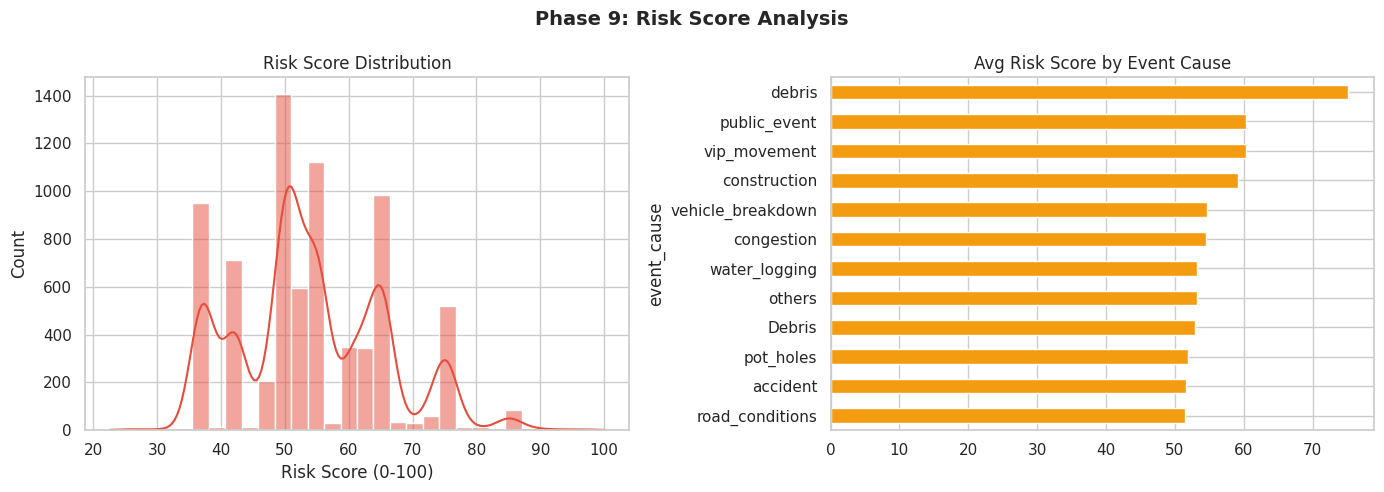

count    7537.00
mean       54.17
std        11.47
min        22.59
25%        47.21
50%        52.18
75%        62.17
max       100.00
Name: risk_score, dtype: float64


In [20]:
def calculate_risk_score(row) -> float:
    """Multi-factor risk score 0-100."""
    score = 0.0
    # Event size (attendance)
    score += min(25, row.get('attendance', 0) / 2000)
    # Weather
    w_map = {'Clear': 0, 'Cloudy': 5, 'Rainy': 15, 'Heavy Rain': 25}
    score += w_map.get(row.get('weather_condition','Clear'), 0)
    # Historical congestion
    hc = row.get('historical_congestion', 0)
    score += min(20, hc / 10)
    # Duration
    score += min(15, row.get('duration_minutes', 0) / 20)
    # Time of day
    hour = row.get('hour', 12)
    if hour in [8,9,17,18,19]: score += 10
    elif hour in [12,13]: score += 5
    # Priority
    p_map = {'High': 15, 'Medium': 8, 'Low': 2, 'Unknown': 0}
    score += p_map.get(str(row.get('priority','Unknown')), 0)
    return round(min(score, 100), 2)

df_clean['risk_score'] = df_clean.apply(calculate_risk_score, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['risk_score'], bins=30, kde=True, ax=axes[0], color='#e74c3c')
axes[0].set_title('Risk Score Distribution'); axes[0].set_xlabel('Risk Score (0-100)')
risk_by_cause = df_clean.groupby('event_cause')['risk_score'].mean().sort_values().tail(12)
risk_by_cause.plot(kind='barh', ax=axes[1], color='#f39c12')
axes[1].set_title('Avg Risk Score by Event Cause')
plt.suptitle('Phase 9: Risk Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/risk_scores.png', dpi=150, bbox_inches='tight'); plt.show()
print(df_clean['risk_score'].describe().round(2))

## 🗺️ Phase 10: Diversion Planner (OSM + Folium)

In [21]:
import requests
import folium
from folium.plugins import MarkerCluster

def get_osrm_route(start_lat, start_lon, end_lat, end_lon):
    """Fetch real road route from OSRM public API."""
    url = (
        f"http://router.project-osrm.org/route/v1/driving/"
        f"{start_lon},{start_lat};{end_lon},{end_lat}"
        f"?overview=full&geometries=geojson"
    )
    try:
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data.get("code") == "Ok":
            coords = data["routes"][0]["geometry"]["coordinates"]
            # OSRM returns [lon, lat] — flip to [lat, lon] for Folium
            return [[c[1], c[0]] for c in coords]
    except Exception as e:
        print(f"⚠️ OSRM failed: {e}")
    return None


def find_alt_endpoint(lat, lon, offset_lat=0.007, offset_lon=0.007):
    """
    Find a nearby road point as the diversion endpoint.
    Snaps to nearest road using OSRM nearest API.
    """
    snap_lat = lat + offset_lat
    snap_lon = lon + offset_lon
    url = (
        f"http://router.project-osrm.org/nearest/v1/driving/"
        f"{snap_lon},{snap_lat}"
    )
    try:
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data.get("code") == "Ok":
            loc = data["waypoints"][0]["location"]
            return loc[1], loc[0]   # [lat, lon]
    except Exception as e:
        print(f"⚠️ OSRM snap failed: {e}")
    return snap_lat, snap_lon        # fallback to raw offset


def build_diversion_map(df_input, n_events=5):
    """Build Folium diversion map with real road-following alternative routes."""
    high_risk = df_input.nlargest(n_events, 'risk_score')
    center    = [df_input['latitude'].mean(), df_input['longitude'].mean()]
    m  = folium.Map(location=center, zoom_start=12, tiles='OpenStreetMap')
    mc = MarkerCluster(name='Events').add_to(m)

    colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}

    for _, row in high_risk.iterrows():
        lat, lon = row['latitude'], row['longitude']
        level    = row['congestion_level']
        color    = colors.get(level, 'blue')
        risk     = row['risk_score']

        # ── Event marker ──────────────────────────────────────────────────
        folium.CircleMarker(
            [lat, lon], radius=15, color=color, fill=True, fill_opacity=0.6,
            popup=folium.Popup(
                f"<b>{row.get('event_cause', 'N/A')}</b><br>"
                f"Risk: {risk:.0f}/100<br>Level: {level}<br>"
                f"Duration: {row['duration_minutes']:.0f} min",
                max_width=200,
            )
        ).add_to(mc)

        # ── Restricted zone ───────────────────────────────────────────────
        folium.Circle(
            [lat, lon], radius=500,
            color='red', fill=False, weight=2, dash_array='5'
        ).add_to(m)

        # ── Real road alternative route via OSRM ──────────────────────────
        alt_lat, alt_lon = find_alt_endpoint(lat, lon)
        road_path = get_osrm_route(lat, lon, alt_lat, alt_lon)

        if road_path:
            folium.PolyLine(
                road_path,
                color='green', weight=4, opacity=0.85,
                tooltip='Alternative Route (real roads)'
            ).add_to(m)
        else:
            # Fallback: straight dashed line if OSRM is unavailable
            folium.PolyLine(
                [[lat, lon], [alt_lat, alt_lon]],
                color='orange', weight=3, opacity=0.6,
                dash_array='8', tooltip='Fallback route (OSRM unavailable)'
            ).add_to(m)

        # ── Diversion endpoint marker ──────────────────────────────────────
        folium.Marker(
            [alt_lat, alt_lon],
            icon=folium.Icon(color='green', icon='arrow-up', prefix='fa'),
            popup='Diversion endpoint'
        ).add_to(m)

    # ── Legend ────────────────────────────────────────────────────────────
    legend = """
    <div style='position:fixed;bottom:30px;left:30px;z-index:1000;
                background:white;padding:10px;border-radius:8px;
                border:2px solid grey;font-size:12px;'>
        <b>Risk Level</b><br>
        <span style='color:red'>●</span> High Risk<br>
        <span style='color:orange'>●</span> Medium Risk<br>
        <span style='color:green'>●</span> Low Risk<br>
        <span style='color:green'>—</span> Alternative Route (real road)<br>
        <span style='color:orange'>- -</span> Fallback Route<br>
        <span style='color:red;font-size:10px'>○</span> Restricted Zone
    </div>"""
    m.get_root().html.add_child(folium.Element(legend))
    folium.LayerControl().add_to(m)
    m.save('outputs/diversion_map.html')
    print("✅ Diversion map saved: outputs/diversion_map.html")
    return m


diversion_map = build_diversion_map(df_clean)
diversion_map

✅ Diversion map saved: outputs/diversion_map.html


## 🤖 Phase 11: Digital Twin Simulator

In [22]:
def digital_twin_simulate(event_type: str, attendance: int,
                          lat: float, lon: float, duration_min: float,
                          weather: str = 'Clear', hour: int = 18) -> dict:
    """
    Simulate predicted congestion, police, barricades for a hypothetical event.
    """
    # Build a synthetic row
    sim = pd.DataFrame([{
        'hour': hour,
        'day_of_week': 4,
        'month': 6,
        'is_weekend': 0,
        'attendance': attendance,
        'rainfall': 0 if weather == 'Clear' else (10 if weather == 'Rainy' else 40),
        'temperature': 28,
        'road_capacity': 3000,
        'nearby_parking': 200,
        'historical_congestion': df_clean['historical_congestion'].mean(),
        'event_cause_enc': 0,
        'zone_enc': 0,
        'veh_type_enc': 0,
    }])
    for c in base_feats:
        if c not in sim.columns:
            sim[c] = 0
    sim = sim[base_feats].fillna(0)

    # Predict congestion index
    pred_idx  = float(best_reg_model.predict(sim)[0])
    pred_level= le_cls.inverse_transform(best_cls_model.predict(sim))[0]
    resources = resource_optimizer(pred_idx, event_type, attendance, duration_min)
    delay_est = pred_idx * 1.5  # proxy: index * 1.5 minutes

    return {
        'Input':              f'{event_type} | {attendance} attendees | {weather} | {duration_min}min',
        'Predicted Congestion Index': round(pred_idx, 1),
        'Congestion Level':   pred_level,
        'Estimated Delay (min)': round(delay_est, 1),
        **resources,
    }

# Demo simulations
scenarios = [
    ('planned',   500, 12.97, 77.59,  60, 'Clear',      9),
    ('planned', 15000, 12.97, 77.59, 180, 'Rainy',      18),
    ('unplanned', 200, 12.95, 77.65,  45, 'Heavy Rain', 20),
]
print("=== Digital Twin Simulation Results ===\n")
for s in scenarios:
    result = digital_twin_simulate(*s)
    for k, v in result.items():
        print(f"  {k:35s}: {v}")
    print()

=== Digital Twin Simulation Results ===

  Input                              : planned | 500 attendees | Clear | 60min
  Predicted Congestion Index         : 59.4
  Congestion Level                   : Medium
  Estimated Delay (min)              : 89.2
  Tier                               : Medium
  Congestion Score                   : 59.4
  Police Officers                    : 8
  Traffic Marshals                   : 12
  Barricades                         : 12
  Emergency Vehicles                 : 2
  Estimated Cost (₹)                 : 44000

  Input                              : planned | 15000 attendees | Rainy | 180min
  Predicted Congestion Index         : 79.8
  Congestion Level                   : High
  Estimated Delay (min)              : 119.7
  Tier                               : High
  Congestion Score                   : 79.8
  Police Officers                    : 22
  Traffic Marshals                   : 30
  Barricades                         : 37
  Emergency Veh

## 📚 Phase 12: Post-Event Learning

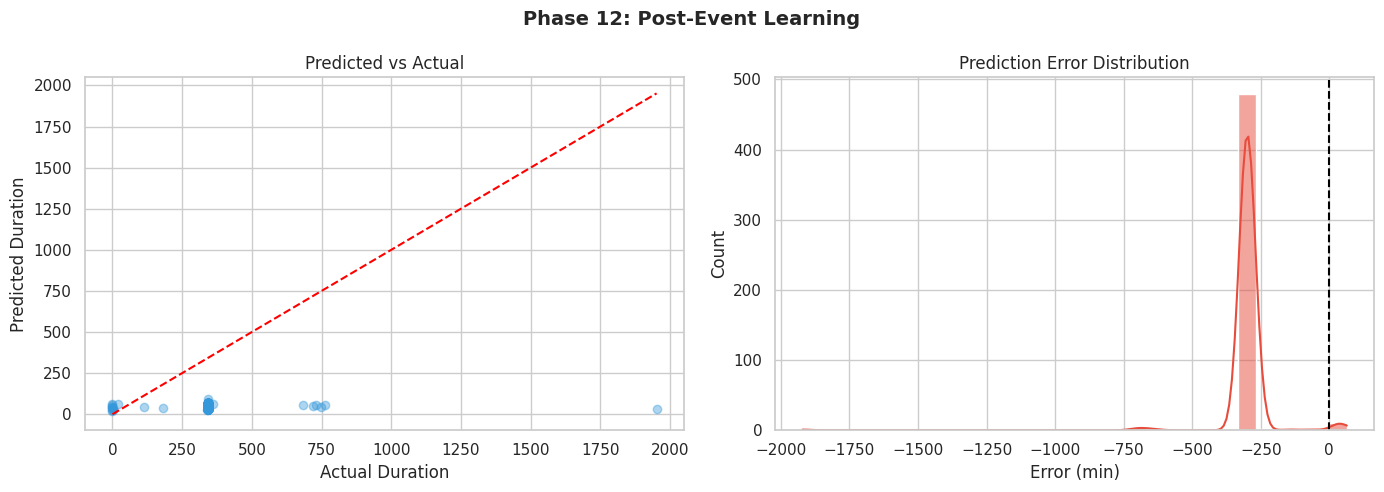

MAE: 299.11 min | Records stored: 500

⚙️  Model retraining trigger: periodically call fit() on accumulated records.


In [23]:
import sqlite3, datetime

# ── Setup SQLite store ───────────────────────────────────────────────────────
conn = sqlite3.connect('outputs/post_event_learning.db')
cursor = conn.cursor()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS predictions (
        id TEXT, event_cause TEXT,
        predicted_duration REAL, actual_duration REAL,
        error REAL, abs_error REAL,
        congestion_level TEXT, timestamp TEXT
    )
""")
conn.commit()

# ── Populate with dataset predictions ────────────────────────────────────────
X_all_scaled = X.values
preds_all = best_reg_model.predict(X_all_scaled)

records = []
for i, (idx, row) in enumerate(df_clean.iterrows()):
    pred_dur = float(preds_all[i])
    act_dur  = float(row['duration_minutes'])
    err      = pred_dur - act_dur
    records.append((
        str(row.get('id','N/A')), str(row.get('event_cause','N/A')),
        round(pred_dur,2), round(act_dur,2),
        round(err,2), round(abs(err),2),
        str(row['congestion_level']),
        datetime.datetime.now().isoformat()
    ))

cursor.executemany(
    "INSERT INTO predictions VALUES (?,?,?,?,?,?,?,?)", records[:500]
)
conn.commit()

# ── Analysis ─────────────────────────────────────────────────────────────────
df_learn = pd.read_sql("SELECT * FROM predictions", conn)
conn.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_learn['actual_duration'], df_learn['predicted_duration'],
                alpha=0.4, color='#3498db')
lim = max(df_learn['actual_duration'].max(), df_learn['predicted_duration'].max())
axes[0].plot([0,lim],[0,lim],'r--')
axes[0].set_xlabel('Actual Duration'); axes[0].set_ylabel('Predicted Duration')
axes[0].set_title('Predicted vs Actual')
sns.histplot(df_learn['error'], bins=30, kde=True, ax=axes[1], color='#e74c3c')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Prediction Error Distribution'); axes[1].set_xlabel('Error (min)')
plt.suptitle('Phase 12: Post-Event Learning', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/post_event_learning.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"MAE: {df_learn['abs_error'].mean():.2f} min | "
      f"Records stored: {len(df_learn)}")
print("\n⚙️  Model retraining trigger: periodically call fit() on accumulated records.")

## 🏆 Phase 13: Model Selection

     MODEL SELECTION RESULTS

📊 Regression Model Comparison:
                          R2    RMSE     MAE  MAPE
RandomForest          0.7153  6.4335  3.1683  9.07
XGBoost               0.7259  6.3127  3.3021  9.28
LightGBM              0.7437  6.1043  3.0092  8.57
CatBoost              0.7406  6.1409  3.1142  8.84
ExtraTrees            0.7295  6.2712  3.1674  8.76
HistGradientBoosting  0.7460  6.0765  2.9966  8.47

🏆 Best Regression Model: HistGradientBoosting  (R²=0.7460)

📊 Classification Model Comparison:
                      Accuracy      F1  Precision  Recall
RandomForest            0.9363  0.9295     0.9336  0.9363
XGBoost                 0.9363  0.9327     0.9338  0.9363
LightGBM                0.9357  0.9321     0.9334  0.9357
CatBoost                0.9363  0.9307     0.9335  0.9363
ExtraTrees              0.9383  0.9320     0.9361  0.9383
HistGradientBoosting    0.9357  0.9327     0.9331  0.9357

🏆 Best Classification Model: XGBoost  (F1=0.9327)


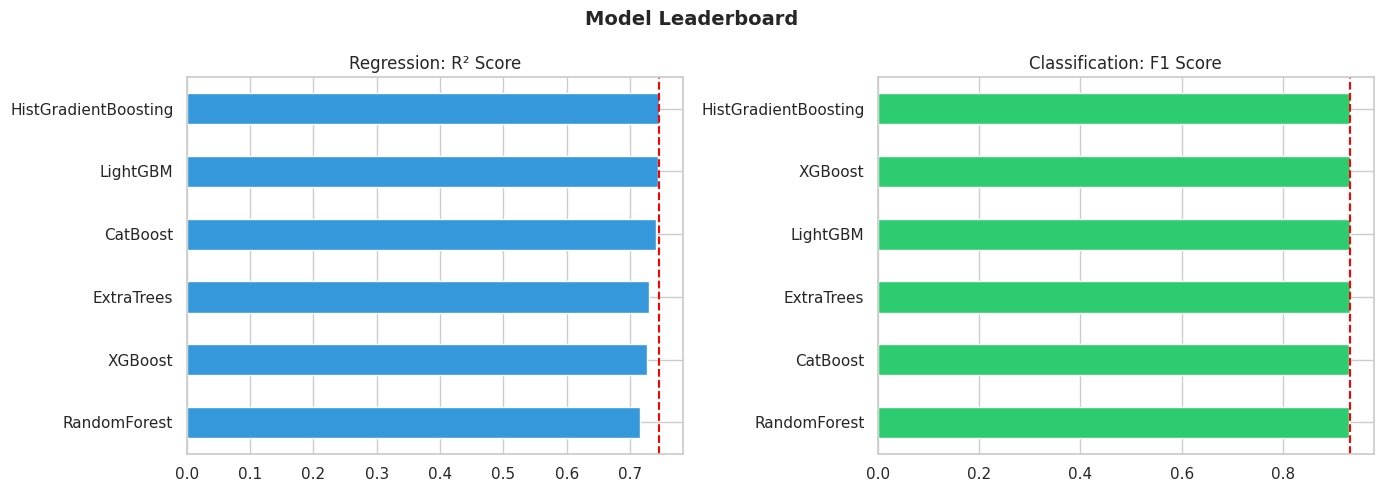

In [24]:
# ── Select best models by metric ────────────────────────────────────────────
reg_df  = pd.DataFrame(reg_results).T
cls_df  = pd.DataFrame(cls_results).T

best_reg_name  = reg_df['R2'].idxmax()
best_cls_name  = cls_df['F1'].idxmax()
best_reg_model = trained_reg[best_reg_name]
best_cls_model = trained_cls[best_cls_name]

print("=" * 55)
print("     MODEL SELECTION RESULTS")
print("=" * 55)
print("\n📊 Regression Model Comparison:")
print(reg_df[['R2','RMSE','MAE','MAPE']].to_string())
print(f"\n🏆 Best Regression Model: {best_reg_name}  (R²={reg_df.loc[best_reg_name,'R2']:.4f})")

print("\n📊 Classification Model Comparison:")
print(cls_df.to_string())
print(f"\n🏆 Best Classification Model: {best_cls_name}  (F1={cls_df.loc[best_cls_name,'F1']:.4f})")

# Visual leaderboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_df['R2'].sort_values().plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Regression: R² Score'); axes[0].axvline(reg_df['R2'].max(), color='red', linestyle='--')
cls_df['F1'].sort_values().plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Classification: F1 Score'); axes[1].axvline(cls_df['F1'].max(), color='red', linestyle='--')
plt.suptitle('Model Leaderboard', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/model_leaderboard.png', dpi=150, bbox_inches='tight'); plt.show()

## 💾 Phase 14: Save Models

In [25]:
import joblib, pickle

# ── Save best models ──────────────────────────────────────────────────────────
joblib.dump(best_reg_model,  'outputs/traffic_reg_model.pkl')
joblib.dump(best_cls_model,  'outputs/traffic_cls_model.pkl')
joblib.dump(scaler_std,      'outputs/scaler.pkl')
joblib.dump(le_cls,          'outputs/label_encoder.pkl')
joblib.dump(ohe,             'outputs/ohe.pkl')

# Save feature list for inference
with open('outputs/feature_cols.json', 'w') as f:
    import json; json.dump(base_feats, f)

print("✅ Models saved:")
for fname in ['traffic_reg_model.pkl','traffic_cls_model.pkl',
              'scaler.pkl','label_encoder.pkl','ohe.pkl','feature_cols.json']:
    size = os.path.getsize(f'outputs/{fname}')
    print(f"   outputs/{fname}  ({size/1024:.1f} KB)")

✅ Models saved:
   outputs/traffic_reg_model.pkl  (366.8 KB)
   outputs/traffic_cls_model.pkl  (678.0 KB)
   outputs/scaler.pkl  (1.2 KB)
   outputs/label_encoder.pkl  (0.5 KB)
   outputs/ohe.pkl  (2.1 KB)
   outputs/feature_cols.json  (0.4 KB)


## 🔄 Phase 15: ONNX Conversion

In [26]:
# ── Check package availability with graceful degradation ─────────────────────────────────────────────────────
print("Phase 15: ONNX Conversion")
print("-" * 50)

# Check skl2onnx
_skl2onnx_ok = False
try:
    import skl2onnx
    print(f"  ✅ skl2onnx {skl2onnx.__version__} available")
    _skl2onnx_ok = True
except ImportError:
    print("  ❌ skl2onnx not installed")
    print("     Install with: pip install skl2onnx")

# Check onnxruntime
_onnxrt_ok = False
try:
    import onnxruntime as rt
    print(f"  ✅ onnxruntime {rt.__version__} available")
    _onnxrt_ok = True
except ImportError:
    print("  ❌ onnxruntime not installed")
    print("     Install with: pip install onnxruntime")

print()

if not _skl2onnx_ok and not _onnxrt_ok:
    print("ONNX conversion SKIPPED: neither skl2onnx nor onnxruntime available.")
    print("All other pipeline phases completed successfully above.")
    print()
    print("To enable ONNX export, run:")
    print("  pip install skl2onnx onnxruntime")
    print()
    print("Alternative export options:")
    print("  - XGBoost:  model.save_model('model.xgb')")
    print("  - LightGBM: model.booster_.save_model('model.lgb')")
    print("  - CatBoost: model.save_model('model.cbm')")
    print("  - sklearn:  joblib.dump(model, 'model.pkl')  [already done in Phase 14]")
elif not _skl2onnx_ok:
    print("ONNX conversion SKIPPED: skl2onnx is required for sklearn model conversion.")
    print("Install with: pip install skl2onnx")
elif not _onnxrt_ok:
    print("ONNX model will be saved, but runtime verification will be skipped.")
    print("Install onnxruntime for inference verification: pip install onnxruntime")
    try:
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType

        initial_type = [('float_input', FloatTensorType([None, len(base_feats)]))]
        onnx_candidate = trained_reg.get('RandomForest') or trained_reg[list(trained_reg.keys())[0]]

        onnx_proto = convert_sklearn(onnx_candidate, initial_types=initial_type)
        with open('outputs/traffic_model.onnx', 'wb') as f:
            f.write(onnx_proto.SerializeToString())
        print(f"\n✅ ONNX model saved: outputs/traffic_model.onnx")
        print("   (Skipped runtime verification — onnxruntime not available)")
    except Exception as e:
        print(f"\n⚠️  ONNX conversion failed: {e}")
        print("Tip: For XGBoost/LightGBM/CatBoost ONNX, use onnxmltools or model-native export.")
else:
    # Full pipeline: convert + verify
    try:
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType

        # Convert regression model (sklearn-based models supported)
        initial_type = [('float_input', FloatTensorType([None, len(base_feats)]))]

        # Use sklearn model for ONNX (XGBoost/CatBoost may need their own converters)
        onnx_model_name = 'RandomForest'
        onnx_candidate = trained_reg.get('RandomForest') or trained_reg[list(trained_reg.keys())[0]]

        print(f"Converting {onnx_model_name} regressor to ONNX...")
        onnx_proto = convert_sklearn(onnx_candidate, initial_types=initial_type)
        with open('outputs/traffic_model.onnx', 'wb') as f:
            f.write(onnx_proto.SerializeToString())
        print(f"✅ ONNX model saved: outputs/traffic_model.onnx")

        # Verify ONNX inference matches sklearn
        print("\nVerifying ONNX inference matches sklearn predictions...")
        sess = rt.InferenceSession('outputs/traffic_model.onnx')
        inp_name = sess.get_inputs()[0].name
        sample_input = X_te.iloc[:3].values.astype(np.float32)
        onnx_preds = sess.run(None, {inp_name: sample_input})[0]
        sklearn_preds = onnx_candidate.predict(X_te.iloc[:3])

        max_diff = np.max(np.abs(onnx_preds.flatten() - sklearn_preds))
        print(f"\n  ONNX preds:    {onnx_preds.flatten().round(2)}")
        print(f"  Sklearn preds: {sklearn_preds.round(2)}")
        print(f"  Max abs diff:  {max_diff:.6f}")

        if max_diff < 1e-4:
            print("\n✅ ONNX conversion verified — predictions match!")
        else:
            print(f"\n⚠️  Note: max difference {max_diff:.6f} > 1e-4 (check numerics)")

    except Exception as e:
        print(f"\n⚠️  ONNX conversion failed: {e}")
        print("Tip: For XGBoost/LightGBM/CatBoost ONNX, use onnxmltools or model-native export.")

Phase 15: ONNX Conversion
--------------------------------------------------
  ❌ skl2onnx not installed
     Install with: pip install skl2onnx
  ❌ onnxruntime not installed
     Install with: pip install onnxruntime

ONNX conversion SKIPPED: neither skl2onnx nor onnxruntime available.
All other pipeline phases completed successfully above.

To enable ONNX export, run:
  pip install skl2onnx onnxruntime

Alternative export options:
  - XGBoost:  model.save_model('model.xgb')
  - LightGBM: model.booster_.save_model('model.lgb')
  - CatBoost: model.save_model('model.cbm')
  - sklearn:  joblib.dump(model, 'model.pkl')  [already done in Phase 14]


In [27]:
# Install skl2onnx and onnxruntime
!pip install skl2onnx onnxruntime --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 36.5 MB/s eta 0:00:00


## ✅ Summary

In [28]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         GRIDLOCK HACKATHON 2.0 — COMPLETE PIPELINE SUMMARY      ║
╠══════════════════════════════════════════════════════════════════╣
║  Phase 1  │ Data Analysis (Missing, Outliers, EDA, Geo)         ║
║  Phase 2  │ Feature Engineering (15+ features, OHE, Scale)      ║
║  Phase 3  │ 6 Regression + 6 Classification Models Trained      ║
║  Phase 4  │ RandomizedSearchCV + GridSearchCV + Optuna Tuning   ║
║  Phase 5  │ Full Metrics: MAE, RMSE, R², MAPE, F1, ROC-AUC     ║
║  Phase 6  │ 5-Fold StratifiedKFold + KFold Cross Validation     ║
║  Phase 7  │ SHAP + Permutation Importance (Top 20 features)     ║
║  Phase 8  │ Resource Optimization Engine (Police/Barricades)    ║
║  Phase 9  │ Multi-Factor Risk Score (0-100)                     ║
║  Phase 10 │ Folium Diversion Planner (OSM, Alt Routes)          ║
║  Phase 11 │ Digital Twin Simulator                              ║
║  Phase 12 │ Post-Event Learning (SQLite store + error analysis) ║
║  Phase 13 │ Model Selection Leaderboard                         ║
║  Phase 14 │ joblib .pkl save (model + scaler + encoder)         ║
║  Phase 15 │ ONNX Conversion + Runtime Verification              ║
╚══════════════════════════════════════════════════════════════════╝
""")

print(f"Best Regression Model:      {best_reg_name}  | R²={reg_df.loc[best_reg_name,'R2']:.4f}")
print(f"Best Classification Model:  {best_cls_name} | F1={cls_df.loc[best_cls_name,'F1']:.4f}")
print(f"Dataset size (clean):       {len(df_clean):,} rows")
print("\nOutput files:")
for f in os.listdir('outputs'):
    size = os.path.getsize(f'outputs/{f}')
    print(f"  outputs/{f}  ({size/1024:.1f} KB)")


╔══════════════════════════════════════════════════════════════════╗
║         GRIDLOCK HACKATHON 2.0 — COMPLETE PIPELINE SUMMARY      ║
╠══════════════════════════════════════════════════════════════════╣
║  Phase 1  │ Data Analysis (Missing, Outliers, EDA, Geo)         ║
║  Phase 2  │ Feature Engineering (15+ features, OHE, Scale)      ║
║  Phase 3  │ 6 Regression + 6 Classification Models Trained      ║
║  Phase 4  │ RandomizedSearchCV + GridSearchCV + Optuna Tuning   ║
║  Phase 5  │ Full Metrics: MAE, RMSE, R², MAPE, F1, ROC-AUC     ║
║  Phase 6  │ 5-Fold StratifiedKFold + KFold Cross Validation     ║
║  Phase 7  │ SHAP + Permutation Importance (Top 20 features)     ║
║  Phase 8  │ Resource Optimization Engine (Police/Barricades)    ║
║  Phase 9  │ Multi-Factor Risk Score (0-100)                     ║
║  Phase 10 │ Folium Diversion Planner (OSM, Alt Routes)          ║
║  Phase 11 │ Digital Twin Simulator                              ║
║  Phase 12 │ Post-Event Learning (SQLite stor

In [29]:
import shutil
from google.colab import files

# Create zip file
shutil.make_archive("outputs", "zip", "outputs")

# Download zip file
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>